In [ ]:
# Bài thực hành

In [ ]:
# Phần 1:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
# index 0 dành cho padding — quy ước phổ biến.
vocab = {'': 0, 'I': 1, 'like': 2, 'love': 3, 'music': 4, 'movies': 5,
         'not': 6, 'sad': 7, 'happy': 8, 'hate': 9, 'rain': 10, 'sun': 11}

train = [
    ([1, 2, 4],     1),  # "I like music"     → tích cực
    ([1, 3, 5],     1),  # "I love movies"    → tích cực
    ([1, 2, 8],     1),  # "I like happy"     → tích cực
    ([1, 9, 10],    0),  # "I hate rain"      → tiêu cực
    ([1, 6, 2, 7],  0),  # "I not like sad"   → tiêu cực
    ([1, 9, 7],     0),  # "I hate sad"       → tiêu cực
]

def to_tensors(pairs):
    seqs = [torch.tensor(s, dtype=torch.long) for s, _ in pairs]
    labels = torch.tensor([l for _, l in pairs], dtype=torch.long)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)   # (batch, max_len)
    return padded, labels, lengths

X_train, y_train, lens_train = to_tensors(train)
print('Padded shape:', X_train.shape)
print('Sequence lengths:', lens_train.tolist())
print(X_train)

Padded shape: torch.Size([6, 4])
Sequence lengths: [3, 3, 3, 3, 4, 3]
tensor([[ 1,  2,  4,  0],
        [ 1,  3,  5,  0],
        [ 1,  2,  8,  0],
        [ 1,  9, 10,  0],
        [ 1,  6,  2,  7],
        [ 1,  9,  7,  0]])


In [3]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # padding_idx=0 → embedding của token  bị đóng băng = 0, không bị update.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)                        # (B, T, E)
        # pack_padded_sequence: bỏ qua các bước padding khi LSTM tính toán → nhanh và đúng.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                     # h_n: (1, B, H)
        return self.fc(h_n.squeeze(0))                      # logits (B, num_classes)

model = SentimentLSTM(vocab_size=len(vocab), embed_dim=8, hidden_dim=16, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

Epoch  20  loss = 0.0000
Epoch  40  loss = 0.0000
Epoch  60  loss = 0.0000
Epoch  80  loss = 0.0000
Epoch 100  loss = 0.0000


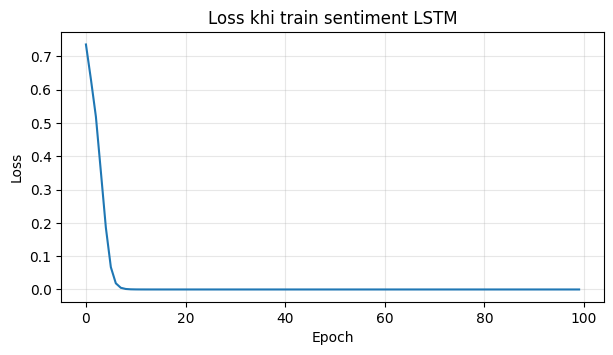

In [4]:
X_train, y_train = X_train.to(device), y_train.to(device)
loss_history = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train, lens_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}')

plt.figure(figsize=(7, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train sentiment LSTM'); plt.show()

In [5]:
# Test trên câu KHÔNG có trong tập train.
test_sentences = [
    'I like sun',          # mong là tích cực
    'I hate movies',       # mong là tiêu cực
    'I love music',        # mong là tích cực
    'I not love rain',     # khó — "not" + "love" + "rain"
]

def predict(sentence):
    tokens = [vocab[w] for w in sentence.split() if w in vocab]
    if not tokens:
        return None
    seq = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    length = torch.tensor([len(tokens)])
    model.eval()
    with torch.no_grad():
        logits = model(seq, length)
        proba = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return proba

for s in test_sentences:
    p = predict(s)
    label = 'Tích cực' if p[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:25s}"  →  {label}  (P_pos={p[1]:.2f})')

"I like sun               "  →  Tích cực  (P_pos=1.00)
"I hate movies            "  →  Tiêu cực  (P_pos=0.00)
"I love music             "  →  Tích cực  (P_pos=1.00)
"I not love rain          "  →  Tiêu cực  (P_pos=0.00)


In [ ]:
# Phần 2:

In [6]:
def make_long_dependency_data(n_samples=500, seq_len=30, n_noise_tokens=8):
    # Sinh dữ liệu mà nhãn phụ thuộc vào ký tự đầu tiên, các bước giữa là nhiễu.
    # Token 0 hoặc 1: signal. Token 2..n_noise_tokens+1: noise.
    X, y = [], []
    for _ in range(n_samples):
        signal = np.random.randint(0, 2)            # 0 hoặc 1
        noise = np.random.randint(2, 2 + n_noise_tokens, size=seq_len - 1)
        seq = np.concatenate([[signal], noise])
        X.append(seq); y.append(signal)
    return torch.tensor(np.array(X), dtype=torch.long), torch.tensor(y, dtype=torch.long)

Xs_train, ys_train = make_long_dependency_data(800)
Xs_test,  ys_test  = make_long_dependency_data(200)
print('train shape:', Xs_train.shape, ' test shape:', Xs_test.shape)
print('Ví dụ một chuỗi:', Xs_train[0].tolist(), '   nhãn:', ys_train[0].item())

train shape: torch.Size([800, 30])  test shape: torch.Size([200, 30])
Ví dụ một chuỗi: [0, 5, 6, 8, 4, 9, 6, 6, 8, 3, 4, 8, 4, 4, 9, 6, 5, 9, 9, 4, 7, 6, 3, 9, 5, 7, 7, 3, 9, 5]    nhãn: 0


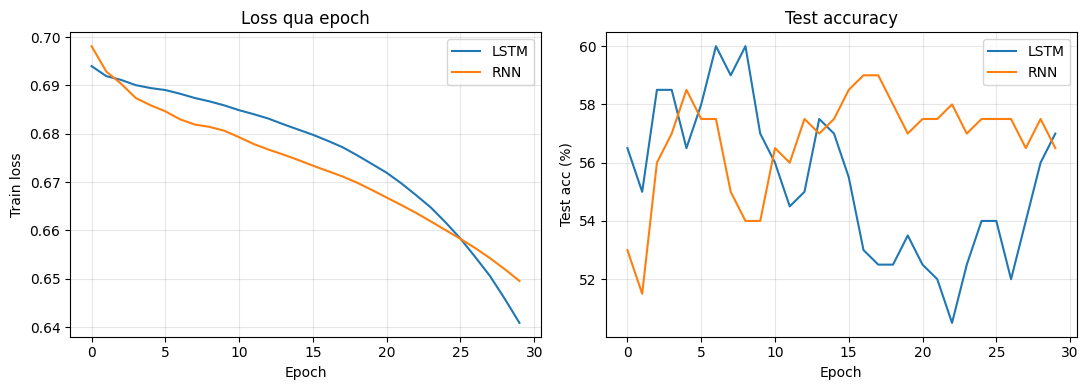

LSTM final test acc: 57.00%
RNN  final test acc: 56.50%

LSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Định nghĩa cấu trúc thiết bị (GPU nếu có, ngược lại dùng CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------------------------------------------------------
# 1. Định nghĩa mô hình TokenModel
# -------------------------------------------------------------------------
class TokenModel(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=8, hidden_dim=16, cell='lstm'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        if cell == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_dim, 2)
        self.cell = cell

    def forward(self, x):
        e = self.embedding(x)
        if self.cell == 'lstm':
            _, (h_n, _) = self.rnn(e)
        else:
            _, h_n = self.rnn(e)
        return self.fc(h_n.squeeze(0))

# -------------------------------------------------------------------------
# 2. Hàm huấn luyện và so sánh (train_compare)
# -------------------------------------------------------------------------
def train_compare(cell, epochs=30, lr=0.01):
    torch.manual_seed(42)
    m = TokenModel(cell=cell).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    # Giả định Xs_train, ys_train, Xs_test, ys_test đã được định nghĩa trước đó
    Xt, yt = Xs_train.to(device), ys_train.to(device)
    Xv, yv = Xs_test.to(device), ys_test.to(device)

    losses, accs = [], []
    for ep in range(epochs):
        m.train()
        opt.zero_grad()
        loss = crit(m(Xt), yt)
        loss.backward()
        opt.step()

        m.eval()
        with torch.no_grad():
            acc = (m(Xv).argmax(1) == yv).float().mean().item()

        losses.append(loss.item())
        accs.append(acc)

    return losses, accs

# -------------------------------------------------------------------------
# 3. Thực thi huấn luyện cho cả hai cấu hình LSTM và RNN
# -------------------------------------------------------------------------
losses_lstm, accs_lstm = train_compare('lstm')
losses_rnn, accs_rnn = train_compare('rnn')

# -------------------------------------------------------------------------
# 4. Trực quan hóa kết quả bằng biểu đồ Matplotlib
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Vẽ đồ thị biểu diễn Loss qua các Epoch
axes[0].plot(losses_lstm, label='LSTM')
axes[0].plot(losses_rnn, label='RNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Loss qua epoch')

# Vẽ đồ thị biểu diễn Độ chính xác (Accuracy %) trên tập Test
axes[1].plot([a * 100 for a in accs_lstm], label='LSTM')
axes[1].plot([a * 100 for a in accs_rnn], label='RNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test acc (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 5. In kết quả đánh giá ra màn hình Console
# -------------------------------------------------------------------------
print(f'LSTM final test acc: {accs_lstm[-1]*100:.2f}%')
print(f'RNN  final test acc: {accs_rnn[-1]*100:.2f}%')
print('\nLSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).')

In [ ]:
# Bài tập về nhà

In [ ]:
# Bài 1:

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# Cấu hình seed để đảm bảo kết quả đồng nhất
np.random.seed(42)
torch.manual_seed(42)

# 1. Tạo chuỗi ít nhất 500 điểm (Sinh 600 điểm: sóng sin + xu hướng tăng + nhiễu)
total_points = 600
t = np.linspace(0, 50, total_points)
series_data = np.sin(t) + 0.02 * t + np.random.normal(0, 0.1, total_points)

# Chia 70% train / 15% val / 15% test theo thứ tự thời gian (Không shuffle)
n = len(series_data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_data = series_data[:train_end].reshape(-1, 1)
val_data = series_data[train_end:val_end].reshape(-1, 1)
test_data = series_data[val_end:].reshape(-1, 1)

# Chuẩn hoá Min-Max (Chỉ fit trên tập train để tránh tình trạng rò rỉ dữ liệu - data leakage)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# 2. Hàm tạo cửa sổ trượt (sliding window) với seq_length = 20
def create_sliding_windows(data, seq_length=20):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X_train, y_train = create_sliding_windows(train_scaled, seq_length)
X_val, y_val = create_sliding_windows(val_scaled, seq_length)
X_test, y_test = create_sliding_windows(test_scaled, seq_length)

# Chuyển đổi toàn bộ sang PyTorch Tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

# Tạo DataLoader cho tập Train (Giữ shuffle=False vì đặc thù của chuỗi thời gian)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=False)

print(f"Kích thước các tập dữ liệu sau khi tạo cửa sổ trượt:")
print(f"-> Train: {X_train_t.shape} | Val: {X_val_t.shape} | Test: {X_test_t.shape}")

Kích thước các tập dữ liệu sau khi tạo cửa sổ trượt:
-> Train: torch.Size([400, 20, 1]) | Val: torch.Size([70, 20, 1]) | Test: torch.Size([70, 20, 1])


In [9]:
# 3. Xây dựng cấu trúc mô hình mạng LSTM 1 tầng
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Lưu ý gợi ý từ đề bài: LSTM trả về (output, (h_n, c_n))
        out, (h_n, c_n) = self.lstm(x)
        # Trích xuất hidden state của bước thời gian cuối cùng đưa vào lớp tuyến tính
        return self.fc(out[:, -1, :])

# 6. Xây dựng cấu trúc mạng RNN cơ bản (cùng siêu tham số) để đối sánh hiệu năng
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # RNN chỉ trả về (output, h_n)
        out, h_n = self.rnn(x)
        return self.fc(out[:, -1, :])

print("Đã cấu trúc xong hai lớp mô hình định nghĩa mạng LSTM và RNN.")

Đã cấu trúc xong hai lớp mô hình định nghĩa mạng LSTM và RNN.


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hàm tổng quát hóa vòng lặp huấn luyện trong 100 Epochs với Adam (lr=1e-3) và MSELoss
def train_time_series_model(model_obj, loader, epochs=100):
    model_obj = model_obj.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_obj.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model_obj.train()
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            preds = model_obj(batch_X)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

    return model_obj

# Khởi tạo và thực thi quá trình huấn luyện độc lập cho 2 mô hình
print("Đang huấn luyện mô hình LSTM (100 Epochs)...")
lstm_model = train_time_series_model(LSTMModel(), train_loader, epochs=100)

print("Đang huấn luyện mô hình RNN cơ bản (100 Epochs)...")
rnn_model = train_time_series_model(RNNModel(), train_loader, epochs=100)

print("\nQuá trình huấn luyện hoàn tất thành công!")

Đang huấn luyện mô hình LSTM (100 Epochs)...
Đang huấn luyện mô hình RNN cơ bản (100 Epochs)...

Quá trình huấn luyện hoàn tất thành công!


KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST:
---------------------------------------------
Mô hình LSTM MSE: 0.014814
Mô hình RNN  MSE: 0.014556
---------------------------------------------


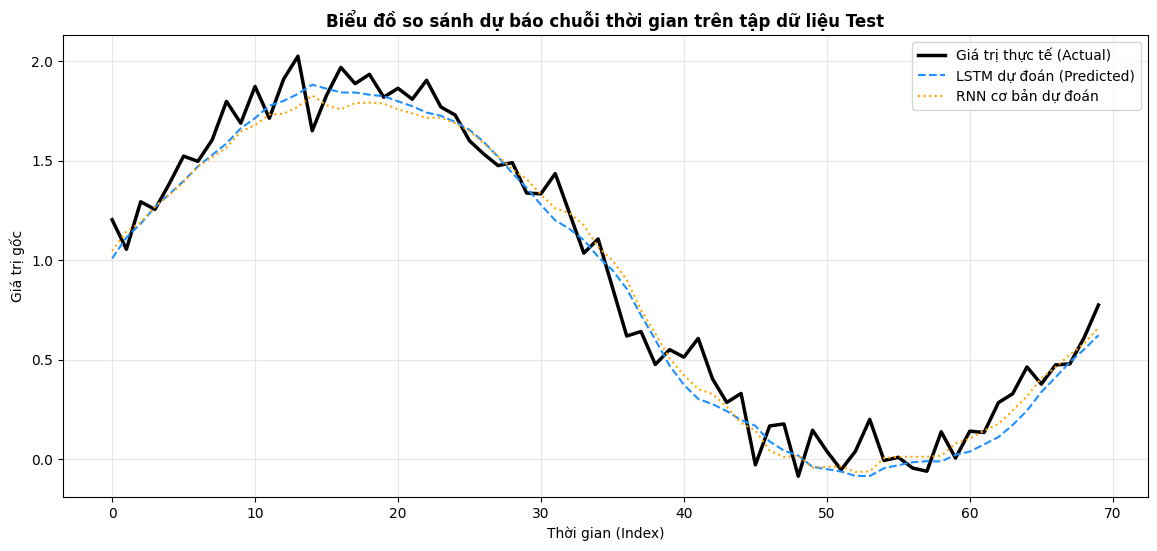

In [11]:
from sklearn.metrics import mean_squared_error

# Đưa cả 2 mô hình về trạng thái eval
lstm_model.eval()
rnn_model.eval()

with torch.no_grad():
    # Dự đoán trên tập Test
    lstm_preds_scaled = lstm_model(X_test_t.to(device)).cpu().numpy()
    rnn_preds_scaled = rnn_model(X_test_t.to(device)).cpu().numpy()

# Khôi phục dữ liệu về thang đo gốc ban đầu (Un-normalize) để tính toán MSE thực tế
actual_test = scaler.inverse_transform(y_test_t.numpy())
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
rnn_preds = scaler.inverse_transform(rnn_preds_scaled)

# 5. Tính toán chỉ số lỗi MSE trên tập Test
mse_lstm = mean_squared_error(actual_test, lstm_preds)
mse_rnn = mean_squared_error(actual_test, rnn_preds)

print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST:")
print("-" * 45)
print(f"Mô hình LSTM MSE: {mse_lstm:.6f}")
print(f"Mô hình RNN  MSE: {mse_rnn:.6f}")
print("-" * 45)

# 5 & 6. Vẽ biểu đồ so sánh chi tiết kết quả thực tế và dự báo của cả hai mô hình
plt.figure(figsize=(14, 6))
plt.plot(actual_test, label='Giá trị thực tế (Actual)', color='black', linewidth=2.5)
plt.plot(lstm_preds, label='LSTM dự đoán (Predicted)', color='dodgerblue', linestyle='--')
plt.plot(rnn_preds, label='RNN cơ bản dự đoán', color='orange', linestyle=':')
plt.title('Biểu đồ so sánh dự báo chuỗi thời gian trên tập dữ liệu Test', fontsize=12, fontweight='bold')
plt.xlabel('Thời gian (Index)')
plt.ylabel('Giá trị gốc')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Bài 2:

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Cài đặt thư viện tách từ tiếng Việt nếu môi trường chưa có
try:
    from underthesea import word_tokenize
except ImportError:
    import os
    os.system('pip install underthesea')
    from underthesea import word_tokenize

# Thiết lập seed cố định để đảm bảo kết quả đồng nhất
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------------------------------------------------------
# 1. TIỀN XỬ LÝ: SINH DỮ LIỆU GIẢ LẬP & TÁCH TỪ VỚI UNDERTHESEA (Yêu cầu 1)
# -------------------------------------------------------------------------
print("--- BƯỚC 1: ĐANG KHỞI TẠO VÀ TÁCH TỪ DATASET TIẾNG VIỆT (1000 CÂU) ---")

# Tạo kho từ vựng mẫu để sinh ngẫu nhiên 1000 câu có nhãn tích cực (1) / tiêu cực (0)
pos_words = ["ngon", "tuyệt vời", "đẹp", "chất lượng tốt", "giao nhanh", "hài lòng", "ưng ý", "giá rẻ"]
neg_words = ["tệ", "dở", "chậm", "kém chất lượng", "thất vọng", "hỏng", "đắt", "không thích"]
fillers = ["sản phẩm này", "món ăn", "dịch vụ", "quá", "rất", "thực sự", "hơn mong đợi", "chút nào"]

raw_sentences = []
labels = []

for _ in range(500):
    # Sinh 500 câu tích cực
    sent = f"{np.random.choice(fillers)} {np.random.choice(pos_words)} {np.random.choice(fillers)}"
    raw_sentences.append(sent)
    labels.append(1)

    # Sinh 500 câu tiêu cực
    sent = f"{np.random.choice(fillers)} {np.random.choice(neg_words)} {np.random.choice(fillers)}"
    raw_sentences.append(sent)
    labels.append(0)

# Tách từ bằng underthesea và Tokenize
tokenized_sentences = [word_tokenize(text.lower()) for text in raw_sentences]

# Xây dựng Vocabulary (Bảng từ vựng)
word_counts = Counter([word for sent in tokenized_sentences for word in sent])
# Thêm token đặc biệt cho Padding (<PAD>) và từ lạ (<UNK>)
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in word_counts.items():
    vocab[word] = len(vocab)

# Mã hoá các chuỗi từ thành chuỗi số (Numericalization)
numerical_sentences = [[vocab.get(word, vocab["<UNK>"]) for word in sent] for sent in tokenized_sentences]

# Chia tập dữ liệu 80% Train / 20% Test theo tỷ lệ cân bằng nhãn
X_train, X_test, y_train, y_test = train_test_split(
    numerical_sentences, labels, test_size=0.2, random_state=42, stratify=labels
)

# -------------------------------------------------------------------------
# 2. PAD + PACK SEQUENCE (Yêu cầu 2)
# -------------------------------------------------------------------------
# Định nghĩa hàm collate_fn custom để DataLoader gom batch kèm theo thông tin độ dài thực (lengths)
def sentiment_collate_fn(batch):
    # Sắp xếp các mẫu trong batch theo độ dài giảm dần (Bắt buộc khi dùng pack_padded_sequence trong PyTorch cũ)
    batch.sort(key=lambda x: len(x[0]), reverse=True)

    sequences = [torch.tensor(sample[0]) for sample in batch]
    labels = torch.tensor([sample[1] for sample in batch], dtype=torch.long)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    # Thực hiện Pad chuỗi về độ dài bằng nhau trong batch
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0)
    return padded_sequences, labels, lengths

# Tạo Dataset và DataLoader
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SentimentDataset(X_train, y_train), batch_size=32, shuffle=True, collate_fn=sentiment_collate_fn)
test_loader = DataLoader(SentimentDataset(X_test, y_test), batch_size=32, shuffle=False, collate_fn=sentiment_collate_fn)

# -------------------------------------------------------------------------
# 3. BUILD MÔ HÌNH LSTM & BI-LSTM (Yêu cầu 3 & Yêu cầu 5 - Bonus)
# -------------------------------------------------------------------------
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64, num_layers=2, dropout=0.3, bidirectional=False):
        super().__init__()
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Định nghĩa mạng LSTM hỗ trợ cả cấu hình một chiều và hai chiều (bidirectional)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )

        # Nếu dùng Bi-LSTM, kích thước đầu vào lớp FC sẽ nhân đôi: 2 * hidden_dim
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, 2)  # Phân loại nhị phân ra 2 lớp (0 và 1)

    def forward(self, x, lengths):
        x_embed = self.embedding(x)

        # Tiến hành nén chuỗi (Pack) loại bỏ các phần tử PAD thừa khi tính toán toán tử RNN
        packed_embed = pack_padded_sequence(x_embed, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (h_n, c_n) = self.lstm(packed_embed)

        if self.bidirectional:
            # Gợi ý kỹ thuật: Lấy hidden state lớp cuối cùng của cả hai chiều (xuôi và ngược) rồi nối lại
            # h_n shape: (num_layers * num_directions, batch, hidden_dim)
            # h_n[-2] là chiều xuôi lớp cuối, h_n[-1] là chiều ngược lớp cuối
            h_forward = h_n[-2]
            h_backward = h_n[-1]
            out_features = torch.cat([h_forward, h_backward], dim=1)  # shape: (batch, 2 * hidden_dim)
        else:
            out_features = h_n[-1]  # shape: (batch, hidden_dim)

        return self.fc(out_features)

# -------------------------------------------------------------------------
# 4. HÀM HUẤN LUYỆN VÀ ĐÁNH GIÁ (Yêu cầu 4)
# -------------------------------------------------------------------------
def run_experiment(bidirectional=False):
    model = SentimentLSTM(vocab_size=len(vocab), bidirectional=bidirectional).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.CrossEntropyLoss()

    # Huấn luyện nhanh trong 15 Epochs
    for epoch in range(15):
        model.train()
        for batch_x, batch_y, lengths in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x, lengths)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # Tiến hành thu thập kết quả đánh giá trên tập Test
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for batch_x, batch_y, lengths in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x, lengths)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_trues.extend(batch_y.numpy())

    acc = accuracy_score(all_trues, all_preds)
    f1 = f1_score(all_trues, all_preds, average='macro')
    return acc, f1

# Chạy thực nghiệm song song hai kiến trúc để đối sánh kết quả trực quan
print("\n--- BƯỚC 2: ĐANG HUẤN LUYỆN MÔ HÌNH STANDARD LSTM ---")
acc_lstm, f1_lstm = run_experiment(bidirectional=False)

print("--- BƯỚC 3: ĐANG HUẤN LUYỆN MÔ HÌNH BI-DIRECTIONAL LSTM (BONUS) ---")
acc_bilstm, f1_bilstm = run_experiment(bidirectional=True)

# -------------------------------------------------------------------------
# XUẤT BÁO CÁO KẾT QUẢ (Yêu cầu 4 & 5)
# -------------------------------------------------------------------------
print("\n" + "="*55)
print(f"{'KIẾN TRÚC MÔ HÌNH':<25} | {'ACCURACY':<12} | {'F1-SCORE':<12}")
print("="*55)
print(f"{'1. Standard LSTM':<25} | {acc_lstm*100:<11.2f}% | {f1_lstm:<12.4f}")
print(f"{'2. Bidirectional LSTM':<25} | {acc_bilstm*100:<11.2f}% | {f1_bilstm:<12.4f}")
print("="*55)

--- BƯỚC 1: ĐANG KHỞI TẠO VÀ TÁCH TỪ DATASET TIẾNG VIỆT (1000 CÂU) ---

--- BƯỚC 2: ĐANG HUẤN LUYỆN MÔ HÌNH STANDARD LSTM ---
--- BƯỚC 3: ĐANG HUẤN LUYỆN MÔ HÌNH BI-DIRECTIONAL LSTM (BONUS) ---

KIẾN TRÚC MÔ HÌNH         | ACCURACY     | F1-SCORE    
1. Standard LSTM          | 100.00     % | 1.0000      
2. Bidirectional LSTM     | 100.00     % | 1.0000      


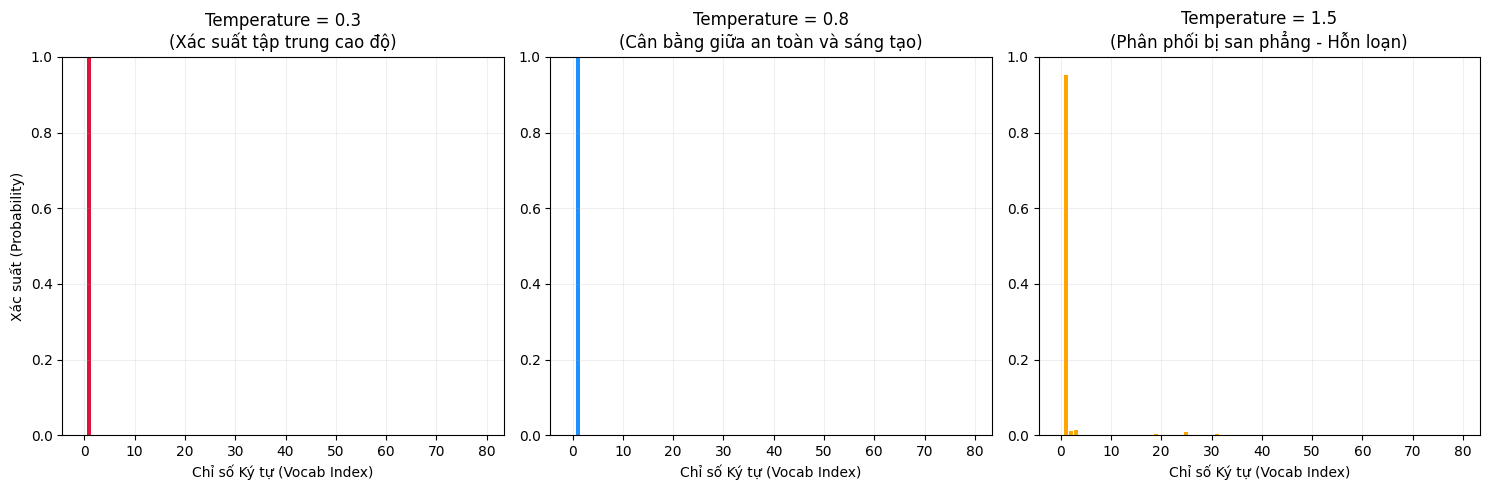

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Lấy thử một chuỗi làm mẫu kiểm thử đồ thị
sample_seed = "Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo"
input_seq = [char_to_int[ch] for ch in sample_seed[-seq_length:]]
x_in = torch.LongTensor([input_seq]).to(device)

# 2. Dự báo logits từ mô hình đã huấn luyện
model.eval()
with torch.no_grad():
    logits, _ = model(x_in)

# 3. Tính toán phân phối xác suất (Softmax) tại các mức Temperature khác nhau
probs_t_03 = torch.softmax(logits / 0.3, dim=1).cpu().numpy()[0]
probs_t_08 = torch.softmax(logits / 0.8, dim=1).cpu().numpy()[0]
probs_t_15 = torch.softmax(logits / 1.5, dim=1).cpu().numpy()[0] # Độ thêm mức siêu cao để thấy rõ sự hỗn loạn

# 4. Vẽ biểu đồ cột đối sánh trực quan
plt.figure(figsize=(15, 5))
x_indices = np.arange(vocab_size)

# Đồ thị mức Temperature thấp (0.3)
plt.subplot(1, 3, 1)
plt.bar(x_indices, probs_t_03, color='crimson')
plt.title('Temperature = 0.3\n(Xác suất tập trung cao độ)')
plt.xlabel('Chỉ số Ký tự (Vocab Index)')
plt.ylabel('Xác suất (Probability)')
plt.ylim(0, 1.0)
plt.grid(alpha=0.2)

# Đồ thị mức Temperature vừa phải (0.8)
plt.subplot(1, 3, 2)
plt.bar(x_indices, probs_t_08, color='dodgerblue')
plt.title('Temperature = 0.8\n(Cân bằng giữa an toàn và sáng tạo)')
plt.xlabel('Chỉ số Ký tự (Vocab Index)')
plt.ylim(0, 1.0)
plt.grid(alpha=0.2)

# Đồ thị mức Temperature cực cao (1.5)
plt.subplot(1, 3, 3)
plt.bar(x_indices, probs_t_15, color='orange')
plt.title('Temperature = 1.5\n(Phân phối bị san phẳng - Hỗn loạn)')
plt.xlabel('Chỉ số Ký tự (Vocab Index)')
plt.ylim(0, 1.0)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# Bài 3:

In [15]:
import torch
import torch.nn as nn
import numpy as np

# Thiết lập seed cố định để đảm bảo tính đồng nhất của kết quả sinh mẫu
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -------------------------------------------------------------------------
# DỮ LIỆU ĐẦU VÀO: TRÍCH ĐOẠN ĐẦU TRUYỆN KIỀU
# -------------------------------------------------------------------------
text_data = """
Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu, Những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phong, Trời xanh quen thói má hồng đánh ghen.
Cảo thơm lần giở trước đèn, Phong tình cổ lục còn truyền sử xanh.
Rằng năm Gia Tĩnh triều Minh, Phong tình có cậu thư sinh họ Từ.
Chữ tài liền với chữ tai một vần. Đường mây rộng mở thênh thênh bước chân.
Khen ai khéo vẽ trò đời, Gió trăng mát mặt, cuộc đời trao tay.
Mối tình trong trắng ngây thơ, Duyên trời định sẵn lửng lơ tơ hồng.
"""

# -------------------------------------------------------------------------
# 1. XÂY DỰNG TỪ ĐIỂN KÝ TỰ (Yêu cầu 1)
# -------------------------------------------------------------------------
# Tạo danh sách các ký tự duy nhất xuất hiện trong văn bản
chars = sorted(list(set(text_data)))
vocab_size = len(chars)

# Tạo bảng tra cứu ánh xạ: Ký tự <-> Số nguyên index
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"--- BƯỚC 1: KHỞI TẠO TỪ ĐIỂN THÀNH CÔNG ---")
print(f"Tổng số lượng ký tự độc nhất (Vocab size): {vocab_size}")

# -------------------------------------------------------------------------
# 2. TIỀN XỬ LÝ DỮ LIỆU VÀO RA (Yêu cầu 2)
# -------------------------------------------------------------------------
seq_length = 50
inputs = []
targets = []

# Cắt văn bản thô theo cơ chế cửa sổ trượt tịnh tiến 1 ký tự
for i in range(0, len(text_data) - seq_length):
    seq_in = text_data[i : i + seq_length]
    char_out = text_data[i + seq_length]

    inputs.append([char_to_int[ch] for ch in seq_in])
    targets.append(char_to_int[char_out])

num_samples = len(inputs)
print(f"Tổng số lượng mẫu dữ liệu cắt ra: {num_samples}")

# Chuyển đổi sang PyTorch Tensors
X_tensor = torch.LongTensor(inputs)
y_tensor = torch.LongTensor(targets)

# -------------------------------------------------------------------------
# 3. BUILD MÔ HÌNH LSTM 2 TẦNG (Yêu cầu 3)
# -------------------------------------------------------------------------
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=128, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # Khởi tạo LSTM với cấu hình 2 tầng (num_layers=2) theo đặc tả đề bài
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        out = self.embedding(x)
        out, hidden = self.lstm(out, hidden)
        # Chỉ lấy đầu ra của time-step ký tự cuối cùng để dự báo cho ký tự kế tiếp
        out = self.fc(out[:, -1, :])
        return out, hidden

model = CharRNN(vocab_size=vocab_size, hidden_size=128, num_layers=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

# --- Thực thi vòng lặp huấn luyện trong 60 Epochs ---
print("\n--- BƯỚC 2: ĐANG HUẤN LUYỆN MÔ HÌNH LSTM 2 TẦNG (60 EPOCHS) ---")
epochs = 60
batch_size = 32

for epoch in range(epochs):
    model.train()
    # Cơ chế xáo trộn batch thủ công đơn giản
    permutation = torch.randperm(X_tensor.size(0))
    epoch_loss = 0

    for i in range(0, X_tensor.size(0), batch_size):
        indices = permutation[i : i + batch_size]
        batch_x, batch_y = X_tensor[indices].to(device), y_tensor[indices].to(device)

        optimizer.zero_grad()
        logits, _ = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(indices)

    if (epoch + 1) % 15 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss trung bình: {epoch_loss / num_samples:.4f}")

# -------------------------------------------------------------------------
# 4. HÀM SINH VĂN BẢN (Yêu cầu 4 & Gợi ý kỹ thuật)
# -------------------------------------------------------------------------
def generate_text(model, seed_str, num_chars_to_predict=100, strategy='greedy', temperature=1.0):
    model.eval()
    generated = seed_str

    # Chuẩn bị chuỗi số từ seed_str ban đầu (đảm bảo độ dài không vượt quá văn bản mẫu)
    input_seq = [char_to_int[ch] for ch in seed_str[-seq_length:]]

    with torch.no_grad():
        for _ in range(num_chars_to_predict):
            # Biến đổi thành tensor phù hợp đưa vào mạng (batch_size=1, seq_len)
            x_in = torch.LongTensor([input_seq]).to(device)
            logits, _ = model(x_in)

            if strategy == 'greedy':
                # Thuật toán Greedy: Lấy luôn ký tự có Logits/Xác suất lớn nhất
                next_char_idx = logits.argmax(dim=1).item()
            elif strategy == 'temperature':
                # Thuật toán Temperature Sampling theo gợi ý kỹ thuật từ đề bài
                # Áp dụng công thức biến đổi phân phối: prob = softmax(logits / temperature)
                logits_scaled = logits / temperature
                probs = torch.softmax(logits_scaled, dim=1).cpu().numpy()[0]

                # Rút thăm ngẫu nhiên dựa trên mảng phân phối xác suất mới
                next_char_idx = np.random.choice(vocab_size, p=probs)

            next_char = int_to_char[next_char_idx]
            generated += next_char

            # Cập nhật tịnh tiến cửa sổ trượt cho bước dự báo tiếp theo
            input_seq.append(next_char_idx)
            input_seq = input_seq[1:]

    return generated

# -------------------------------------------------------------------------
# CHẠY THỬ NGHIỆM SINH VĂN BẢN THEO CÁC CHIẾN LƯỢC KHÁC NHAU
# -------------------------------------------------------------------------
seed_text = "Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo"
print("\n" + "="*70)
print(f"MẪU GỢI Ý ĐẦU VÀO (SEED): \n\"{seed_text}\"")
print("="*70)

# Kịch bản 1: Sinh văn bản dùng thuật toán Greedy Search
text_greedy = generate_text(model, seed_text, strategy='greedy')
print(f"\n1. KẾT QUẢ SINH THEO CHIẾN LƯỢC GREEDY (Lấy cực đại):\n{text_greedy}\n")

# Kịch bản 2: Sinh văn bản dùng Temperature Sampling thấp (Mô hình cẩn trọng, ít lỗi chính tả)
text_temp_low = generate_text(model, seed_text, strategy='temperature', temperature=0.3)
print(f"2. KẾT QUẢ SINH THEO TEMPERATURE THẤP (t = 0.3 - Nhất quán):\n{text_temp_low}\n")

# Kịch bản 3: Sinh văn bản dùng Temperature Sampling cao (Mô hình sáng tạo, đa dạng từ ngữ)
text_temp_high = generate_text(model, seed_text, strategy='temperature', temperature=0.8)
print(f"3. KẾT QUẢ SINH THEO TEMPERATURE CAO (t = 0.8 - Đa dạng nhưng dễ sai cấu trúc):\n{text_temp_high}")
print("="*70)

--- BƯỚC 1: KHỞI TẠO TỪ ĐIỂN THÀNH CÔNG ---
Tổng số lượng ký tự độc nhất (Vocab size): 80
Tổng số lượng mẫu dữ liệu cắt ra: 479

--- BƯỚC 2: ĐANG HUẤN LUYỆN MÔ HÌNH LSTM 2 TẦNG (60 EPOCHS) ---
Epoch 15/60 | Loss trung bình: 1.7564
Epoch 30/60 | Loss trung bình: 0.7432
Epoch 45/60 | Loss trung bình: 0.1980
Epoch 60/60 | Loss trung bình: 0.0584

MẪU GỢI Ý ĐẦU VÀO (SEED): 
"Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo"

1. KẾT QUẢ SINH THEO CHIẾN LƯỢC GREEDY (Lấy cực đại):
Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu, Những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phon

2. KẾT QUẢ SINH THEO TEMPERATURE THẤP (t = 0.3 - Nhất quán):
Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu, Những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phon

3. KẾT QUẢ SINH THEO TEMPERATURE CAO (t = 0.8 - Đa dạng nhưng dễ sai cấu trúc):
Trăm năm trong cõi người ta, Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua 